# Music Genre Classifer MLP


## Libraries


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
from random import random
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from pathlib import Path
import json
from collections import defaultdict

## GPU


In [2]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Device: {device}")

Device: mps


## Data


In [3]:
# load data
def load_data(dataset_path):
    with open(dataset_path, "r") as f:
        data = json.load(f)

    # convert lists into numpy arrays
    inputs = np.array(data["mfcc"])
    targets = np.array(data["labels"])

    return inputs, targets

In [4]:
# split the data into train and test sets
data_path = Path("../data/audio-deep-learning/mfcc_data.json")
inputs, targets = load_data(data_path)
inputs_train, inputs_test, targets_train, targets_test = train_test_split(
    inputs, targets, test_size=0.3
)

input_train = torch.from_numpy(inputs_train).float()
input_test = torch.from_numpy(inputs_test).float()
target_train = torch.from_numpy(targets_train).long()
target_test = torch.from_numpy(targets_test).long()

train_dataset = TensorDataset(input_train, target_train)
test_dataset = TensorDataset(input_test, target_test)

train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=32)


## PyTorch Multi-Layer Perceptron


In [5]:
class MusicGenreClassifierMLP(nn.Module):
    def __init__(self, time_steps, n_mfcc, num_classes=10):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(time_steps * n_mfcc, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Linear(64, num_classes),
        )

    def forward(self, x):
        return self.net(x)


def evaluate(model, dataloader, loss_fn, device=torch.device("cpu")):
    model.to(device)
    model.eval()
    test_loss, test_correct, test_total = 0.0, 0, 0

    with torch.inference_mode():
        for x_batch, y_batch in dataloader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            preds = model(x_batch)
            loss = loss_fn(preds, y_batch)

            test_loss += loss.item() * x_batch.size(0)
            test_correct += (preds.argmax(1) == y_batch).sum().item()
            test_total += y_batch.size(0)

    avg_test_loss = test_loss / test_total
    avg_test_acc = test_correct / test_total
    return avg_test_loss, avg_test_acc


def train(
    model,
    train_loader,
    test_loader,
    optimizer,
    loss_fn,
    epochs=100,
    device=torch.device("cpu"),
):
    history = defaultdict(list)
    model.to(device)

    for epoch in range(epochs):
        model.train()
        train_loss, train_correct, train_total = 0.0, 0, 0

        for x_batch, y_batch in train_loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)

            optimizer.zero_grad(set_to_none=True)
            preds = model(x_batch)
            loss = loss_fn(preds, y_batch)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * x_batch.size(0)
            train_correct += (preds.argmax(1) == y_batch).sum().item()
            train_total += y_batch.size(0)

        # Evaluate on validation/test set
        test_loss, test_acc = evaluate(model, test_loader, loss_fn, device)

        avg_train_loss = train_loss / train_total
        train_acc = train_correct / train_total

        history["train_loss"].append(avg_train_loss)
        history["train_acc"].append(train_acc)
        history["test_loss"].append(test_loss)
        history["test_acc"].append(test_acc)

        print(
            f"Epoch {epoch + 1:3d}/{epochs} | "
            f"train_loss: {avg_train_loss:.4f} - train_acc: {train_acc:.4f} | "
            f"test_loss: {test_loss:.4f} - test_acc: {test_acc:.4f}"
        )

    print("========================")
    print("Training Finished!\n")
    return history


## Plot Results


In [6]:
def plot_history(history):
    fig, axs = plt.subplots(2, figsize=(10, 8))

    # create accuracy subplot
    axs[0].plot(history["train_acc"], label="train accuracy")
    axs[0].plot(history["test_acc"], label="test accuracy")
    axs[0].set_ylabel("Accuracy")
    axs[0].legend(loc="best")
    axs[0].set_title("Accuracy eval")

    # create error subplot
    axs[1].plot(history["train_loss"], label="train error")
    axs[1].plot(history["test_loss"], label="test error")
    axs[1].set_ylabel("Error")
    axs[1].set_xlabel("Epoch")
    axs[1].legend(loc="best")
    axs[1].set_title("Error eval")

    fig.tight_layout()
    plt.show()

## Testing


In [7]:
if __name__ == "__main__":
    model = MusicGenreClassifierMLP(inputs.shape[1], inputs.shape[2]).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)
    loss_fn = nn.CrossEntropyLoss()

    model_history = train(
        model=model,
        train_loader=train_dataloader,
        test_loader=test_dataloader,
        optimizer=optimizer,
        loss_fn=loss_fn,
        epochs=50,
        device=device,
    )


Epoch   1/50 | train_loss: 1.6327 - train_acc: 0.4217 | test_loss: 1.4696 - test_acc: 0.4640
Epoch   2/50 | train_loss: 1.2706 - train_acc: 0.5501 | test_loss: 1.2888 - test_acc: 0.5234
Epoch   3/50 | train_loss: 1.1028 - train_acc: 0.6097 | test_loss: 1.1972 - test_acc: 0.5741
Epoch   4/50 | train_loss: 0.9918 - train_acc: 0.6471 | test_loss: 1.2775 - test_acc: 0.5534
Epoch   5/50 | train_loss: 0.8567 - train_acc: 0.7056 | test_loss: 1.1593 - test_acc: 0.5935
Epoch   6/50 | train_loss: 0.7732 - train_acc: 0.7349 | test_loss: 1.1420 - test_acc: 0.6061
Epoch   7/50 | train_loss: 0.6792 - train_acc: 0.7672 | test_loss: 1.1556 - test_acc: 0.6025
Epoch   8/50 | train_loss: 0.5877 - train_acc: 0.8082 | test_loss: 1.1084 - test_acc: 0.6218
Epoch   9/50 | train_loss: 0.5162 - train_acc: 0.8279 | test_loss: 1.1640 - test_acc: 0.6145
Epoch  10/50 | train_loss: 0.4338 - train_acc: 0.8592 | test_loss: 1.1008 - test_acc: 0.6365
Epoch  11/50 | train_loss: 0.3759 - train_acc: 0.8783 | test_loss: 1.1

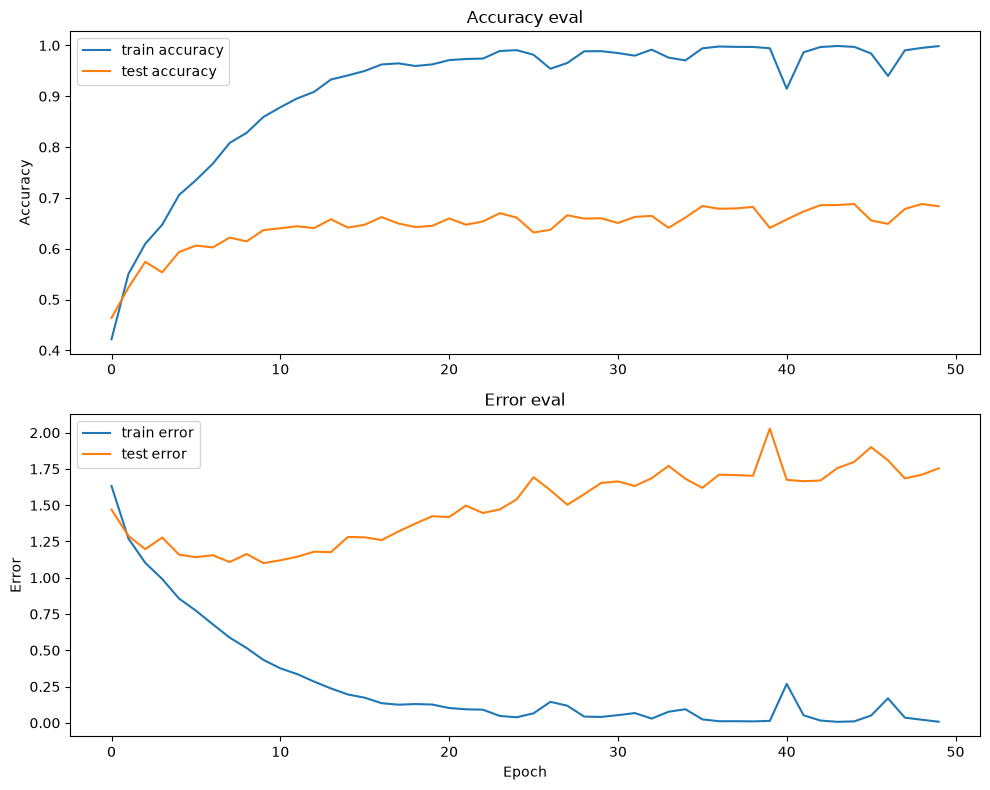

In [8]:
# plot accuracy and error over the epochs
plot_history(model_history)